In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error
import copy

In [2]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Шум Гаусса

In [3]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)

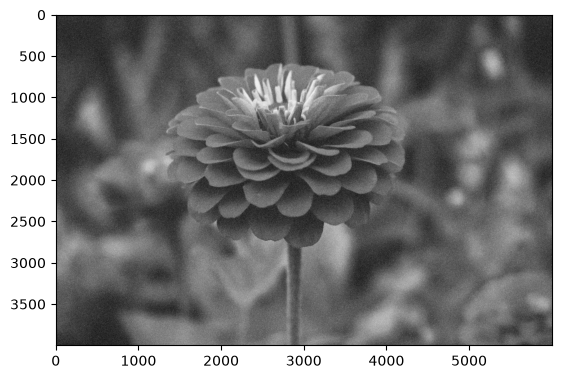

In [4]:
plt.imshow(image_noise_gauss, cmap="gray")

In [5]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print(mse_gauss, ssim_gauss)

4498.495616958333 0.025890101157439005


# Постоянный шум

In [6]:
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)

image_sp = copy.deepcopy(image_gray)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255

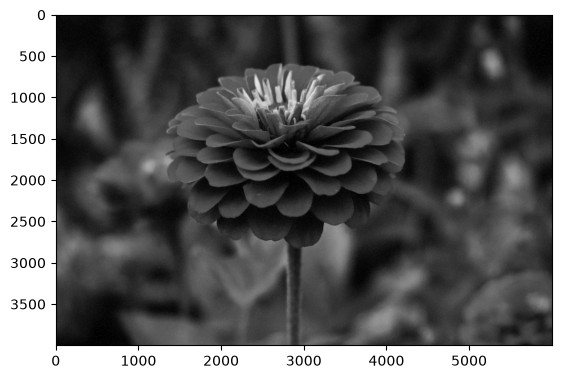

In [7]:
plt.imshow(image_sp, cmap="gray")

In [8]:
mse_sp = mean_squared_error(image_gray, image_sp)
(ssim_sp, diff) = structural_similarity(image_gray, image_sp, full=True)
print(mse_sp, ssim_sp)

446.51527154166666 0.5492648292932784


# Медианный фильтр

In [9]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
mse_gauss_median = mean_squared_error(image_gray, image_gauss_median)
(ssim_gauss_median, diff) = structural_similarity(image_gray, image_gauss_median, full=True)
print(mse_gauss_median, ssim_gauss_median)

844.0684315833333 0.1536194148874991


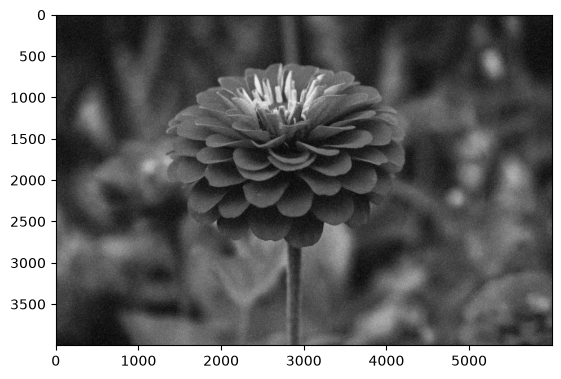

In [10]:
plt.imshow(image_gauss_median, cmap="gray")

In [11]:
image_sp_median = cv2.medianBlur(image_sp, 3)
mse_sp_median = mean_squared_error(image_gray, image_sp_median)
(ssim_sp_median, diff) = structural_similarity(image_gray, image_sp_median, full=True)
print(mse_sp_median, ssim_sp_median)

7.717730625 0.9115550787131944


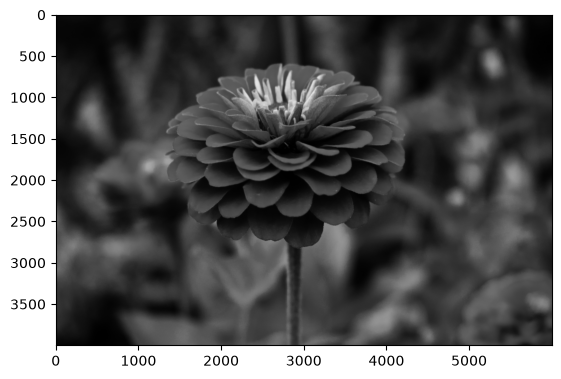

In [12]:
plt.imshow(image_sp_median, cmap="gray")

# Фильтр Гаусса

In [13]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5,5), 0)
mse_gauss_gauss = mean_squared_error(image_gray, image_gauss_gauss)
(ssim_gauss_gauss, diff) = structural_similarity(image_gray, image_gauss_gauss, full=True)
print(mse_gauss_gauss, ssim_gauss_gauss)

1729.2054128333334 0.2304045520784348


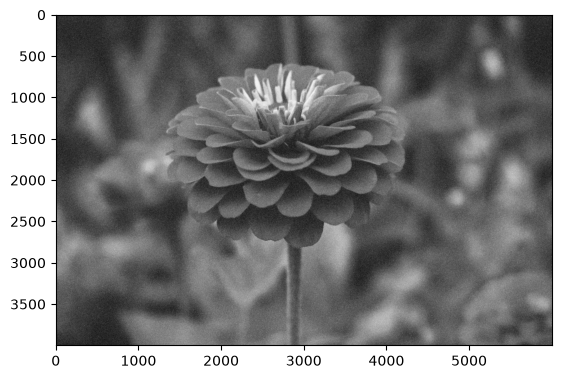

In [14]:
plt.imshow(image_gauss_gauss, cmap="gray")

In [15]:
image_sp_gauss = cv2.GaussianBlur(image_sp, (5,5), 0)
mse_sp_gauss = mean_squared_error(image_gray, image_sp_gauss)
(ssim_sp_gauss, diff) = structural_similarity(image_gray, image_sp_gauss, full=True)
print(mse_sp_gauss, ssim_sp_gauss)

43.407213041666665 0.7124996438888562


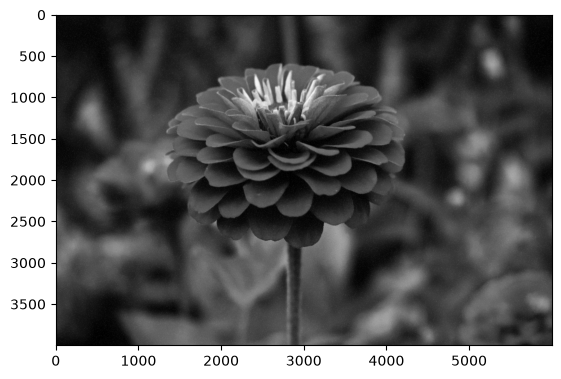

In [16]:
plt.imshow(image_sp_gauss, cmap="gray")

# Билатеральный фильтр

In [17]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
mse_gauss_bilat = mean_squared_error(image_gray, image_gauss_bilat)
(ssim_gauss_bilat, diff) = structural_similarity(image_gray, image_gauss_bilat, full=True)
print(mse_gauss_bilat, ssim_gauss_bilat)

1786.3903612083334 0.1045069515651392


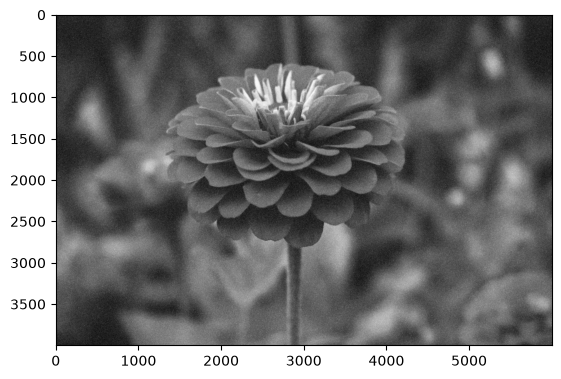

In [18]:
plt.imshow(image_gauss_bilat, cmap="gray")

In [19]:
image_sp_bilat = cv2.bilateralFilter(image_sp, 9, 75, 75)
mse_sp_bilat = mean_squared_error(image_gray, image_sp_bilat)
(ssim_sp_bilat, diff) = structural_similarity(image_gray, image_sp_bilat, full=True)
print(mse_sp_bilat, ssim_sp_bilat)

172.22992375 0.6290056520121156


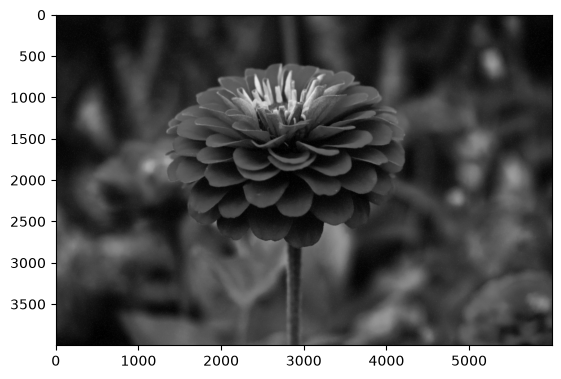

In [20]:
plt.imshow(image_sp_bilat, cmap="gray")

# Фильтр нелокальных средних

In [21]:
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
mse_gauss_nlm = mean_squared_error(image_gray, image_gauss_nlm)
(ssim_gauss_nlm, diff) = structural_similarity(image_gray, image_gauss_nlm, full=True)
print(mse_gauss_nlm, ssim_gauss_nlm)

4486.269640875 0.028931002176420983


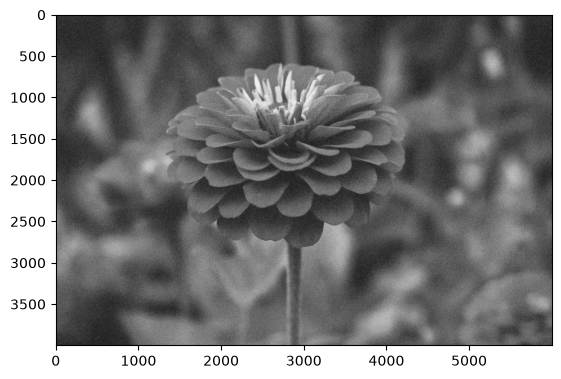

In [22]:
plt.imshow(image_gauss_nlm, cmap="gray")

In [23]:
image_sp_nlm = cv2.fastNlMeansDenoising(image_sp, h = 20)
mse_sp_nlm = mean_squared_error(image_gray, image_sp_nlm)
(ssim_sp_nlm, diff) = structural_similarity(image_gray, image_sp_nlm, full=True)
print(mse_sp_nlm, ssim_sp_nlm)

64.79333870833334 0.7500050005007632


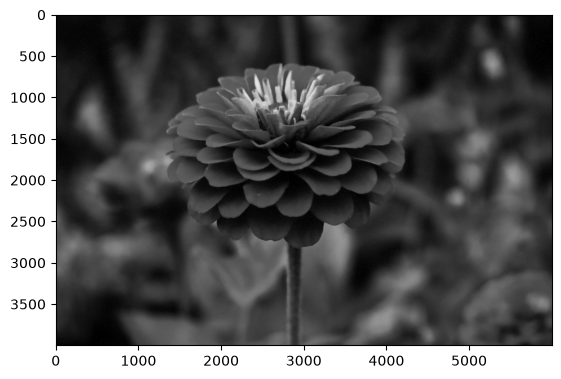

In [24]:
plt.imshow(image_sp_nlm, cmap="gray")

# Сравнение фильтров

Пары (MSE, SSIM)
## Для шума Гаусса
Медианный фильтр
844.0684315833333 0.1536194148874991

Фильтр Гаусса
1729.2054128333334 0.2304045520784348

Билатеральный фильтр
1786.3903612083334 0.1045069515651392

Фильтр нелокальных средних
4486.269640875 0.028931002176420983

##### Лучший - по MSE медианный, по SSIM Фильтр Гаусса

## Для постоянного шума
Медианный фильтр
7.717730625 0.9115550787131944

Фильтр Гаусса
43.407213041666665 0.7124996438888562

Билатеральный фильтр
172.22992375 0.6290056520121156

Фильтр нелокальных средних
64.79333870833334 0.7500050005007632

##### Лучший - Медианный фильтр